In [46]:
import torch
import sys, os
sys.path.append(os.path.abspath('../'))
from src.models.gpt import INRGPT
from src.data.dataset import INRDataset
class YamlConfig:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)
train_dataset = INRDataset(folder_path="../data/processed_inrs_1", split='train')
sample_idx = 0
sample = train_dataset[sample_idx]
# 1. Setup device and load your config/checkpoint
device = 'cpu'
checkpoint_path = "../checkpoints/inr_gpt.pt"

# Load the saved state
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
config = checkpoint['config'] # Assumes you saved your config object
model = INRGPT(config)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# 1. Slice it directly (no torch.tensor() constructor)
init_token = torch.tensor([200], dtype=torch.long)

# 2. Move to device (ensure it's long type for indices)
init_token = init_token.to(device=device, dtype=torch.long)

# 3. Add the batch dimension (1, 1184)
init_token = init_token.unsqueeze(0)

# 3. Generate the rest of the weights
# You have 1185 total weights, so you need 1184 *new* tokens 
# (the init token is already the first one)
print("Generating new network weights...")
generated_sequence = model.generate(
    init_token, 
    max_new_tokens=1185, 
    temperature=0.15, # 0.8 is a good start, use 1.0 for more variety
    top_k=None     # Limits the pool to top 50 likely tokens to reduce noise
)

# 4. Result
print(f"Generated sequence shape: {generated_sequence.shape}\n")
#torch.set_printoptions(threshold=float('inf'))

#print(f"This is GPT: {generated_sequence[:20].squeeze(0)}")
#print(f"This is original: {sample['x_tokens'][:100]}")
with open("tensors_data_gpt.txt", "w") as f:
    f.write("Tensor A values:\n")
    for val in generated_sequence.squeeze(0).tolist():
        f.write(f"{val}\n")
print(f"{sample['x_tokens'].shape}")
with open("tensors_data_og.txt", "w") as f:
    f.write("Tensor A values:\n")
    for val in torch.cat([sample["x_tokens"][1:], sample["y_tokens"][-1:]]).tolist():
        f.write(f"{val}\n")

# generated_indices = generated_sequence[0] # This is your list of 1185 token indices!

number of parameters: 0.02M
Generating new network weights...
Generated sequence shape: torch.Size([1, 1186])

torch.Size([1185])


In [35]:
torch.save({
    'tokens': generated_sequence[:,1:],           # Your live [65, 33] tensor
    'layer_ids': sample['layer_ids'].cpu()
}, "data/temp_generated.pt")
from src.utils.prepare_data import INRDataProcessor
processor = INRDataProcessor()
state_dict = processor.reconstruct_state_dict("data/temp_generated.pt")

# 3. Save your final functional model file
torch.save(state_dict, "data/final_reconstructed_model.pth")

🚀 Passing perfectly shaped dimensions through BatchSiren...
🎨 Rendering image...


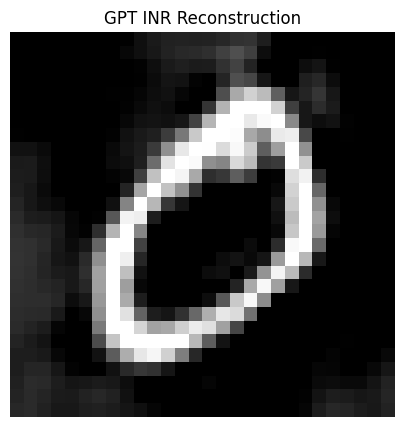

In [36]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path
current_dir = Path(os.getcwd())
sys.path.append(str(Path("..") / "external" / "neuralgraphs"))
from experiments.data import BatchSiren

# 1. Setup basic dimensions
img_shape = (28, 28)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load your raw .pth dictionary file directly
checkpoint = torch.load("data/final_reconstructed_model.pth", map_location=device)

# 3. Shape the tensors exactly how BatchSiren's Einops layers demand them:
# Weights need to be: [batch_size=1, in_features, out_features, 1]
# Note: PyTorch saves weights as [out_features, in_features], so we transpose them (.T) to match (i, o)
w0 = checkpoint["seq.0.weight"].T.unsqueeze(0).unsqueeze(-1)  # [1, 2, 32, 1]
w1 = checkpoint["seq.1.weight"].T.unsqueeze(0).unsqueeze(-1)  # [1, 32, 32, 1]
w2 = checkpoint["seq.2.weight"].T.unsqueeze(0).unsqueeze(-1)  # [1, 32, 1, 1]

# Biases need to be: [batch_size=1, out_features, 1]
b0 = checkpoint["seq.0.bias"].unsqueeze(0).unsqueeze(-1)      # [1, 32, 1]
b1 = checkpoint["seq.1.bias"].unsqueeze(0).unsqueeze(-1)      # [1, 32, 1]
b2 = checkpoint["seq.2.bias"].unsqueeze(0).unsqueeze(-1)      # [1, 1, 1]

# 4. Group them into lists matching the layer-by-layer zip structure
weights_input = [w0.float()/199 - 0.5, w1.float()/199 - 0.5, w2.float()/199 - 0.5]
biases_input = [b0.float()/199 - 0.5, b1.float()/199 - 0.5, b2.float()/199 - 0.5]

# 5. Initialize the model and run the forward pass
# (hidden_features=32 matches the layers in your file)
inr_model = BatchSiren(2, 1, hidden_features=32, img_shape=img_shape).to(device)
inr_model.eval()

print("🚀 Passing perfectly shaped dimensions through BatchSiren...")

with torch.no_grad():
    # This will now pass smoothly through the zip loop and Rearrange functions!
    out = inr_model(weights_input, biases_input)
    
    # Reshape the output pixels back into the 2D image matrix
    out_image = out.transpose(1, 2).unflatten(2, img_shape)

print("🎨 Rendering image...")

# 6. Render and show the image
plt.figure(figsize=(5, 5))
plt.imshow(make_grid(out_image.cpu()).permute(1, 2, 0).clip(0, 1))
plt.title("GPT INR Reconstruction")
plt.axis("off")
plt.show()